<a href="https://colab.research.google.com/github/jth202515033/ABCD-A/blob/20250515/20250515yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralyti

100%|██████████| 49.7M/49.7M [00:00<00:00, 354MB/s]


Saving 스크린샷 2025-05-15 141142.png to 스크린샷 2025-05-15 141142.png


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


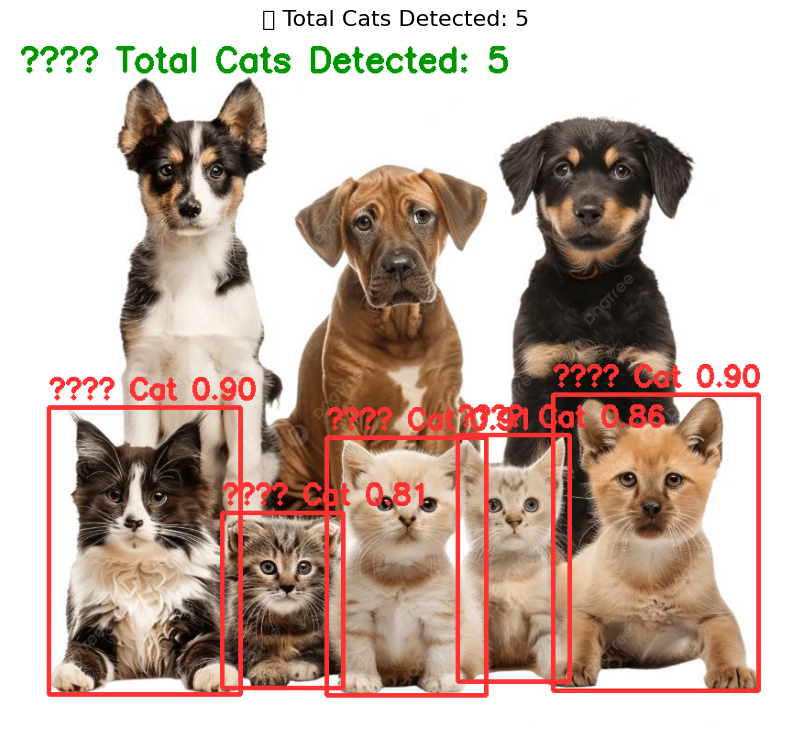

In [1]:
!pip install ultralytics --upgrade -q

# 2. 모듈 임포트
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import cv2
import matplotlib.pyplot as plt

# 3. 더 큰 YOLOv8 모델 로드 (정확도 중시: yolov8m.pt)
model = YOLO("yolov8m.pt")

# 4. 이미지 업로드
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# 5. 이미지 저장
img = Image.open(img_path).convert("RGB")
img.save("input.jpg")

# 6. 추론 수행 (conf=0.4로 높임)
results = model.predict(source="input.jpg", conf=0.4, verbose=False)

# 7. 고양이 클래스 필터링
names = model.names
cat_class_ids = [i for i, name in names.items() if "cat" in name.lower()]
boxes = results[0].boxes
cat_boxes = [box for box in boxes if int(box.cls) in cat_class_ids]
cat_count = len(cat_boxes)

# 8. 시각화 (굵은 박스 + 더 큰 글씨)
image = cv2.imread("input.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

for box in cat_boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])
    label = f"🐱 Cat {conf:.2f}"
    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 50, 50), 4)  # 더 굵고 진한 색
    cv2.putText(image, label, (x1, max(20, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 50, 50), 3)

# 9. 고양이 수 출력
summary_text = f"🐾 Total Cats Detected: {cat_count}"
cv2.putText(image, summary_text, (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 150, 0), 4)

# 10. 시각화 출력
plt.figure(figsize=(12, 9))
plt.imshow(image)
plt.axis('off')
plt.title(summary_text, fontsize=16)
plt.show()

Saving 스크린샷 2025-05-15 141218.png to 스크린샷 2025-05-15 141218.png


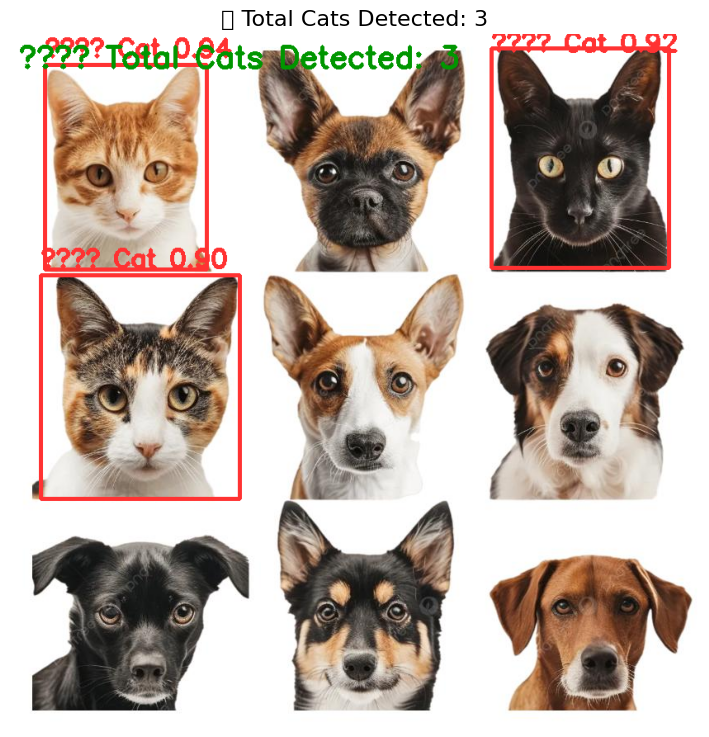

In [2]:
!pip install ultralytics --upgrade -q

# 2. 모듈 임포트
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import cv2
import matplotlib.pyplot as plt

# 3. 더 큰 YOLOv8 모델 로드 (정확도 중시: yolov8m.pt)
model = YOLO("yolov8m.pt")

# 4. 이미지 업로드
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# 5. 이미지 저장
img = Image.open(img_path).convert("RGB")
img.save("input.jpg")

# 6. 추론 수행 (conf=0.4로 높임)
results = model.predict(source="input.jpg", conf=0.4, verbose=False)

# 7. 고양이 클래스 필터링
names = model.names
cat_class_ids = [i for i, name in names.items() if "cat" in name.lower()]
boxes = results[0].boxes
cat_boxes = [box for box in boxes if int(box.cls) in cat_class_ids]
cat_count = len(cat_boxes)

# 8. 시각화 (굵은 박스 + 더 큰 글씨)
image = cv2.imread("input.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

for box in cat_boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])
    label = f"🐱 Cat {conf:.2f}"
    cv2.rectangle(image, (x1, y1), (x2, y2), (255, 50, 50), 4)  # 더 굵고 진한 색
    cv2.putText(image, label, (x1, max(20, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 50, 50), 3)

# 9. 고양이 수 출력
summary_text = f"🐾 Total Cats Detected: {cat_count}"
cv2.putText(image, summary_text, (10, 40),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 150, 0), 4)

# 10. 시각화 출력
plt.figure(figsize=(12, 9))
plt.imshow(image)
plt.axis('off')
plt.title(summary_text, fontsize=16)
plt.show()